In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models

# ----------------------------------------------------------
# 1. Load X_train and dataset to align 24h targets
# ----------------------------------------------------------
X_train = np.load("X_train.npy")   # shape = (n_samples, 24, 35)
df = pd.read_csv("dataset_mansion_features.csv", parse_dates=["MTime"])

WINDOW = 24
TARGET_STEPS = 24

# ----------------------------------------------------------
# 2. Build true next-24 target array
# ----------------------------------------------------------
true_24 = []

cons = df["Consumption"].values

for i in range(len(cons) - WINDOW - TARGET_STEPS):
    next24 = cons[i + WINDOW : i + WINDOW + TARGET_STEPS]
    true_24.append(next24)

true_24 = np.array(true_24, dtype=np.float32)

# Align lengths
X_24 = X_train[:len(true_24)]

print("X_24 shape:", X_24.shape)
print("true_24 shape:", true_24.shape)

# ----------------------------------------------------------
# 3. Build TCN 24-output Model (replacing GRU)
# ----------------------------------------------------------
def build_tcn_24(
    window,
    features,
    target_steps,
    num_filters=64,
    kernel_size=3,
    dilations=(1, 2, 4, 8),
    dropout_rate=0.2,
):
    inputs = layers.Input(shape=(window, features))
    x = inputs

    for d in dilations:
        conv = layers.Conv1D(
            filters=num_filters,
            kernel_size=kernel_size,
            dilation_rate=d,
            padding="causal",
            activation="relu",
        )(x)
        conv = layers.Dropout(dropout_rate)(conv)

        if x.shape[-1] != num_filters:
            res = layers.Conv1D(num_filters, 1, padding="same")(x)
        else:
            res = x

        x = layers.Add()([conv, res])
        x = layers.LayerNormalization()(x)

    # Pool over time and output 24 future steps
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(target_steps)(x)   # 24-hour output vector

    model = models.Model(inputs, outputs)
    model.compile(
        optimizer="adam",
        loss="mse",
        metrics=["mae"],
    )
    return model


model = build_tcn_24(
    window=WINDOW,
    features=X_train.shape[-1],
    target_steps=TARGET_STEPS,
)

model.summary()

# ----------------------------------------------------------
# 4. Train Model
# ----------------------------------------------------------
history = model.fit(
    X_24, true_24,
    epochs=25,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
)

# ----------------------------------------------------------
# 5. Save Model (TCN)
# ----------------------------------------------------------
# NOTE: this will overwrite tcn_model.keras from 1-hour if in same folder
model.save("tcn_model.keras")
print("TCN 24-hour model training complete! Saved as tcn_model.keras")


X_24 shape: (41427, 24, 35)
true_24 shape: (56183, 24)


2025-12-04 22:14:55.189668: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 35)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 64)    │      6,784 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │      2,304 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 64)    │          0 │ dropout[0][0],    │
│                     │                   │            │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 24, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 24, 64)    │          0 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 64)    │          0 │ dropout_1[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 24, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 64)    │          0 │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 64)    │          0 │ dropout_2[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 24, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 64)    │          0 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 64)    │          0 │ dropout_3[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_average_p

 Total params: 52,376 (204.59 KB)

 Trainable params: 52,376 (204.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.8205 - mae: 0.5285 - val_loss: 0.2788 - val_mae: 0.3596
Epoch 2/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - loss: 0.0742 - mae: 0.1691 - val_loss: 0.2007 - val_mae: 0.2628
Epoch 3/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0568 - mae: 0.1400 - val_loss: 0.1968 - val_mae: 0.2507
Epoch 4/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0536 - mae: 0.1325 - val_loss: 0.2700 - val_mae: 0.2744
Epoch 5/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0410 - mae: 0.1110 - val_loss: 0.2818 - val_mae: 0.2856
Epoch 6/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0361 - mae: 0.1022 - val_loss: 0.2742 - val_mae: 0.2933
Epoch 7/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 0.0325 - mae: 0.0953 - val_loss: 0.2900 - val_mae: 0.2955
Epoch 8/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0320 - mae: 0.0914 - val_loss: 0.2721 - val_mae: 0.2672
Epoch 9/25
583/583 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/

In [3]:
import numpy as np
import tensorflow as tf

# ----------------------------------------------------------
# 1. Load TCN 24-hour model and eval windows
# ----------------------------------------------------------
model = tf.keras.models.load_model("tcn_model.keras")
X_eval = np.load("X_eval.npy")   # shape: (n_eval, 24, features)

print("X_eval shape:", X_eval.shape)

# ----------------------------------------------------------
# 2. Predict next 24 hours for each eval window
# ----------------------------------------------------------
y_pred_24 = model.predict(X_eval, verbose=1)   # shape: (n_eval, 24)

np.save("y_pred_24_tcn.npy", y_pred_24)
print("Saved y_pred_24_tcn.npy with shape:", y_pred_24.shape)


X_eval shape: (5785, 24, 35)
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Saved y_pred_24_tcn.npy with shape: (5785, 24)


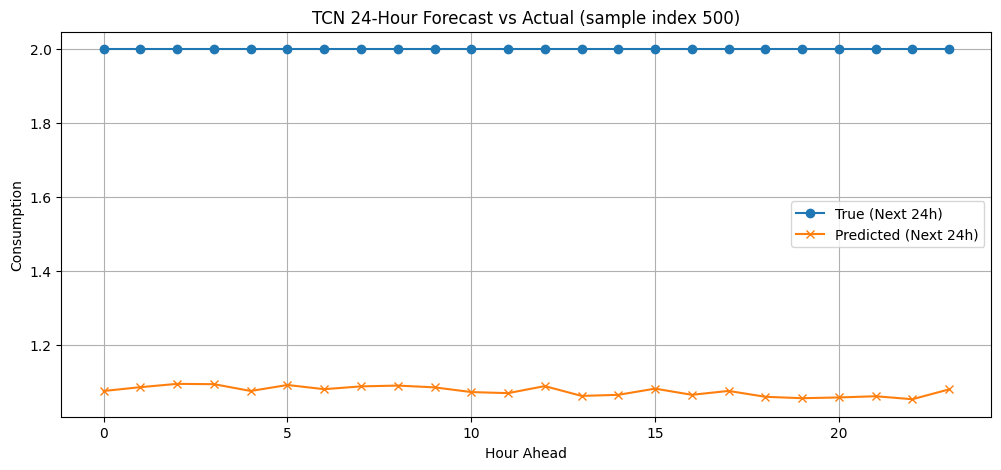

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# If in a fresh session, reload these:
# true_24 = np.load("true_24.npy")  # if you decide to save it
# y_pred_24 = np.load("y_pred_24_tcn.npy")

sample_idx = 500
sample_idx = min(sample_idx, len(y_pred_24) - 1, len(true_24) - 1)

plt.figure(figsize=(12, 5))
plt.plot(true_24[sample_idx], label="True (Next 24h)", marker="o")
plt.plot(y_pred_24[sample_idx], label="Predicted (Next 24h)", marker="x")
plt.title(f"TCN 24-Hour Forecast vs Actual (sample index {sample_idx})")
plt.xlabel("Hour Ahead")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.show()


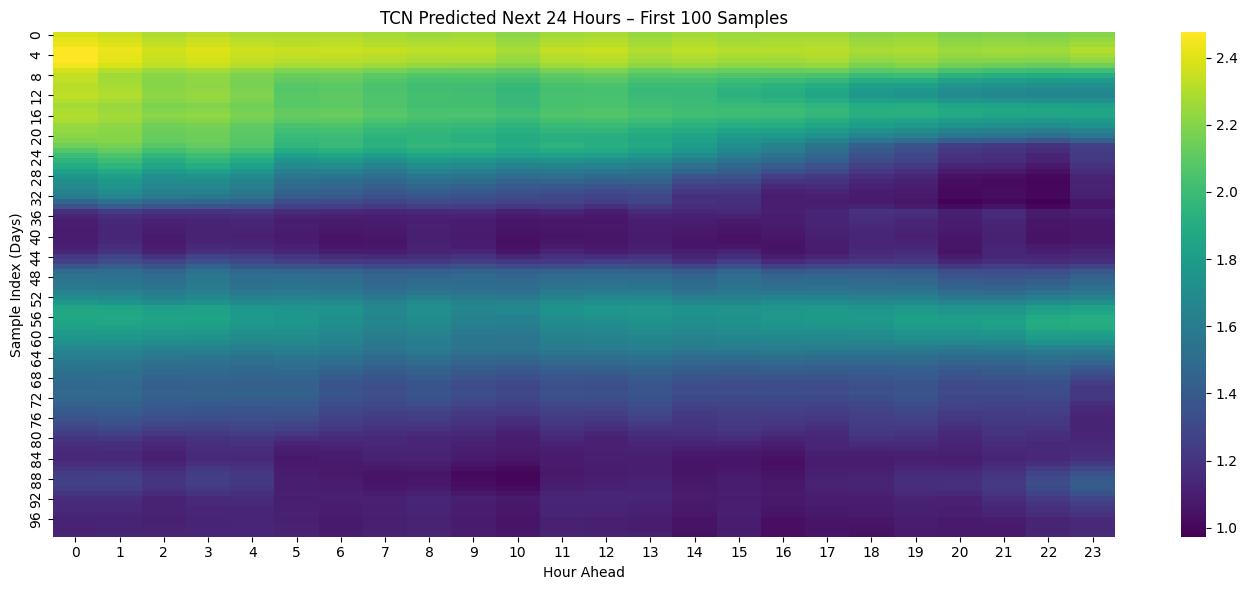

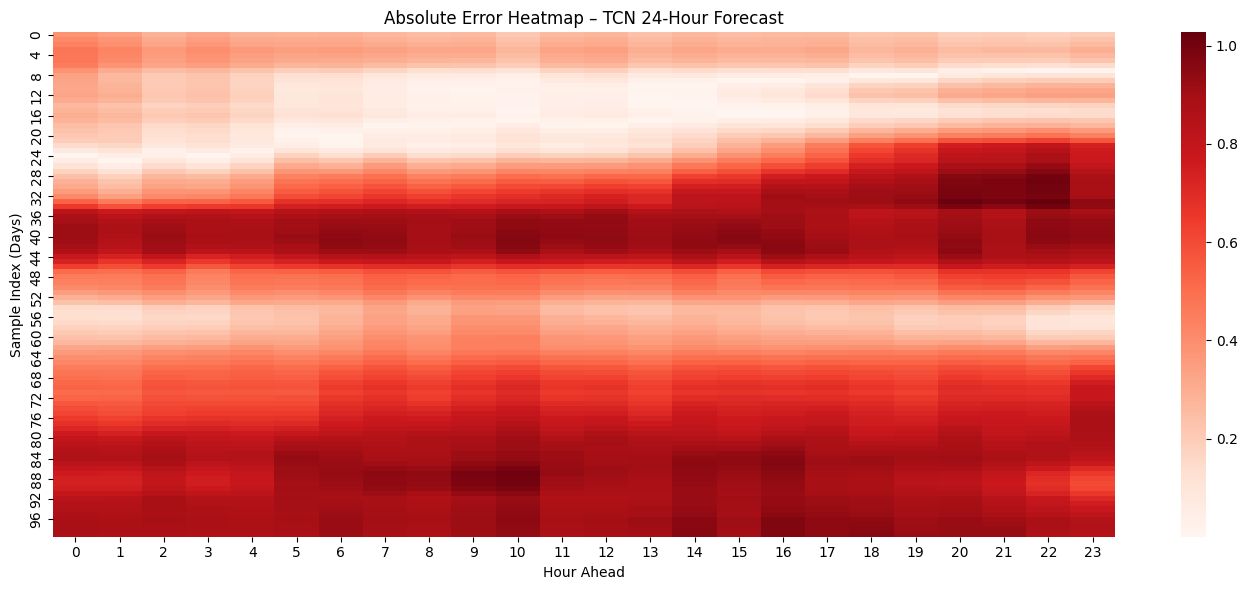

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# If needed:
# y_pred_24 = np.load("y_pred_24_tcn.npy")

# Make sure lengths match
min_len = min(len(true_24), len(y_pred_24))
true_24_aligned = true_24[:min_len]
y_pred_24_aligned = y_pred_24[:min_len]

# ----------------------------------------------------------
# Heatmap of predicted next 24h for first 100 samples
# ----------------------------------------------------------
plt.figure(figsize=(14, 6))
sns.heatmap(y_pred_24_aligned[:100], cmap="viridis")
plt.title("TCN Predicted Next 24 Hours – First 100 Samples")
plt.xlabel("Hour Ahead")
plt.ylabel("Sample Index (Days)")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Absolute error heatmap
# ----------------------------------------------------------
errors = np.abs(true_24_aligned - y_pred_24_aligned)

plt.figure(figsize=(14, 6))
sns.heatmap(errors[:100], cmap="Reds")
plt.title("Absolute Error Heatmap – TCN 24-Hour Forecast")
plt.xlabel("Hour Ahead")
plt.ylabel("Sample Index (Days)")
plt.tight_layout()
plt.show()
